# Clustering — Exercise 7: Image Color Compression with K-Means

**Course:** Introduction to Machine Learning and Applied Artificial Intelligence
**Institution:** High School of Digital Culture, ITMO University


<a href="https://colab.research.google.com/github/Mir-robotics/ITMO-Introduction-to-Machine-Learning-and-Applied-Artificial-Intelligence/blob/main/Clustering%202/Clustering_Exercise_7.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


Clustering isn't just for abstract feature tables — it has a genuinely useful,
visual application: **color quantization** (reducing the number of distinct colors in
an image). The idea is simple: treat every pixel's RGB value as a 3-dimensional data
point, cluster those points into $k$ groups with K-means, and replace every pixel with
its cluster's centroid color. Similar, nearby colors get merged into one — a form of
lossy image compression.


## 0. Setup and data loading

> **Note on data access:** this notebook works with a specific photograph (of St.
> Isaac's Cathedral, St. Petersburg) that was originally loaded from the author's
> Google Drive. That image is included in this repository at
> `data/1.jpg` so the notebook runs out of the box.


Mounted at /content/drive


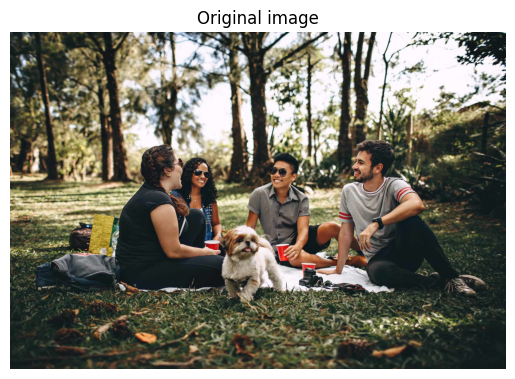

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

IMG_PATH = "data/1.jpg"

img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV loads as BGR; convert to RGB for display

plt.axis("off")
plt.imshow(img)
plt.title("Original image")
plt.show()


## 1. Inspect and normalize pixel intensities

The image is a three-channel (RGB) image with 8-bit integer values (0-255) per
channel. Let's check the average intensity across all channels, then normalize to the
[0, 1] range — a standard preprocessing step that also makes the numbers easier to
interpret as "how bright, as a fraction of maximum."


In [3]:
average_intensity = img.mean()
print(f"Average pixel intensity (0-255 scale): {round(average_intensity, 3)}")


Average pixel intensity (0-255 scale): 98.066


In [4]:
img_normalized = img / 255

average_intensity_normalized = img_normalized.mean()
print(f"Average pixel intensity (0-1 scale): {round(average_intensity_normalized, 3)}")


Average pixel intensity (0-1 scale): 0.385


## 2. Visualize the color space

The original color space has about 16 million possible colors ($256^3$), far more
than any image actually needs to look good. To see this visually, we "flatten" the
image from a `(height, width, 3)` array into a plain list of RGB pixels — a
`(height * width, 3)` array — and plot a random subsample of those pixels in two 2D
color-channel slices.


In [5]:
img_flat = img_normalized.reshape(-1, 3)
print(f"Flattened shape: {img_flat.shape}")


Flattened shape: (3352998, 3)


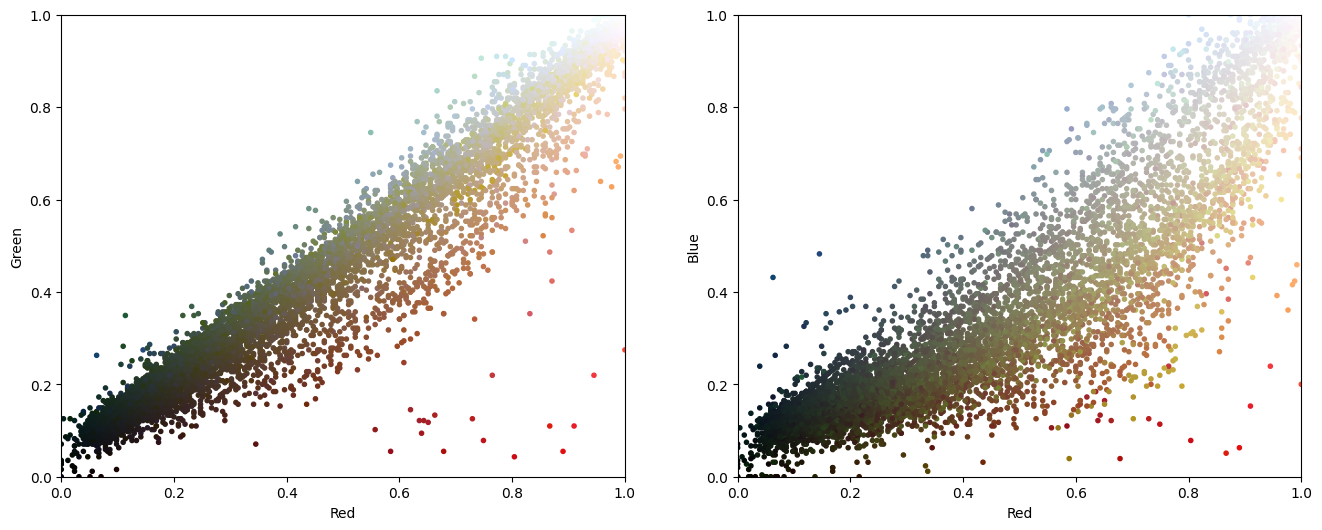

In [6]:
def plot_pixels(data, colors=None, n_samples=10000):
    """Scatter-plot a random subsample of RGB pixels in Red-Green and Red-Blue slices."""
    if colors is None:
        colors = data

    rng = np.random.RandomState(0)
    sample_idx = rng.permutation(data.shape[0])[:n_samples]
    sampled_colors = colors[sample_idx]
    R, G, B = data[sample_idx].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=sampled_colors, marker=".")
    ax[0].set(xlabel="Red", ylabel="Green", xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=sampled_colors, marker=".")
    ax[1].set(xlabel="Red", ylabel="Blue", xlim=(0, 1), ylim=(0, 1))

    plt.show()


plot_pixels(img_flat)


## 3. Reduce to 16 colors with K-means

Now for the actual compression: we cluster all the pixels into just 16 groups and
replace every pixel with its cluster's centroid color. We use `MiniBatchKMeans`
rather than plain `KMeans` — it processes small random batches of the data instead of
the whole set at once, trading a little bit of precision for a big speedup on the
hundreds of thousands of pixels in a typical photo.


In [7]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import MiniBatchKMeans

N_COLORS = 16

mb_kmeans = MiniBatchKMeans(n_clusters=N_COLORS, random_state=10).fit(img_flat)
palette = mb_kmeans.cluster_centers_


In [8]:
# Map each pixel to its cluster's centroid color, then reshape back to image dimensions
pixel_labels = mb_kmeans.labels_.reshape(img_normalized.shape[0], img_normalized.shape[1])
img_compressed = palette[pixel_labels]

compressed_intensity = img_compressed.mean()
print(f"Average pixel intensity of the compressed image: {round(compressed_intensity, 3)}")


Average pixel intensity of the compressed image: 0.385


### Re-visualize the (now much sparser) color space

With only 16 possible colors instead of millions, the same Red-Green / Red-Blue
scatter plot should collapse down to 16 distinct clumps.


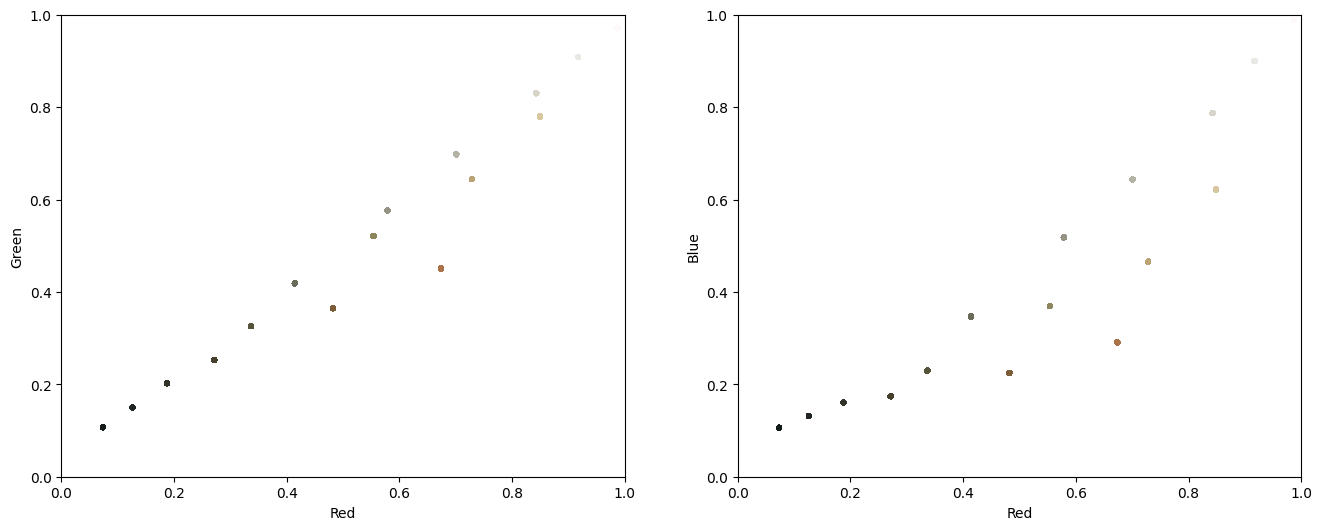

In [9]:
plot_pixels(img_compressed.reshape(-1, 3), colors=palette[mb_kmeans.labels_])


## 4. Visualize the extracted 16-color palette


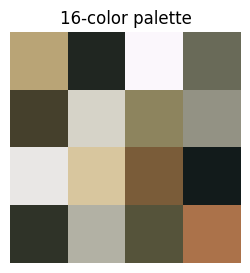

In [10]:
palette_grid = palette.reshape(4, 4, 3)

plt.figure(figsize=(3, 3))
plt.imshow(palette_grid)
plt.axis("off")
plt.title("16-color palette")
plt.show()


## 5. Compare the original and compressed images side by side


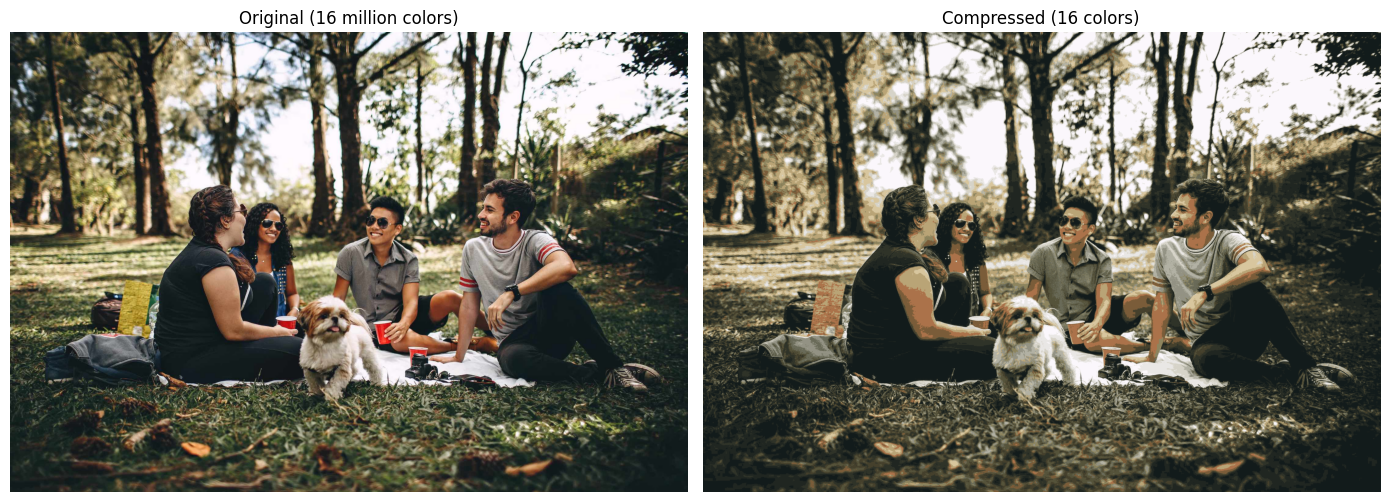

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(img)
axes[0].set_title("Original (16 million colors)")
axes[0].axis("off")

axes[1].imshow(img_compressed)
axes[1].set_title(f"Compressed ({N_COLORS} colors)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Summary

- K-means doesn't need to operate on abstract "features" — raw pixel colors work
  perfectly well as 3-dimensional data points, which is all K-means needs.
- Reducing 16 million possible colors down to just 16 clusters produces a visibly
  "posterized" image, but one that's still clearly recognizable — most of the visual
  information in a photograph lives in far fewer distinct colors than the full color
  space allows.
- `MiniBatchKMeans` is a practical, drop-in substitute for `KMeans` whenever the
  number of data points (here, pixels) is large enough that fitting on the full
  dataset in one shot becomes slow — a very common situation for image and other
  high-volume data.
